In [6]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit 

In [7]:
df = pd.read_csv("noisy_curvefit_data.csv")
df.head()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [8]:
df.shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()
df.tail()

df.columns

Rows: 100
Columns: 6


Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')

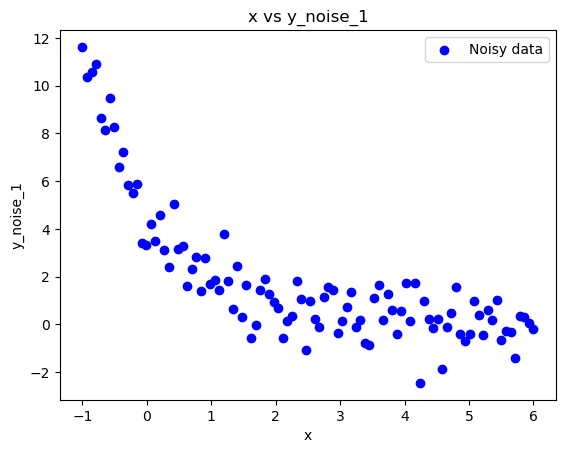

In [9]:
plt.scatter(df["x"], df["y_noise_1"], color="blue", label = "Noisy data")

plt.xlabel("x")
plt.ylabel("y_noise_1")
plt.title("x vs y_noise_1")
plt.legend()

plt.show()

Fit: y = 4.71 * e^(-0.92 * x)
Reduced chi-squared: 0.79


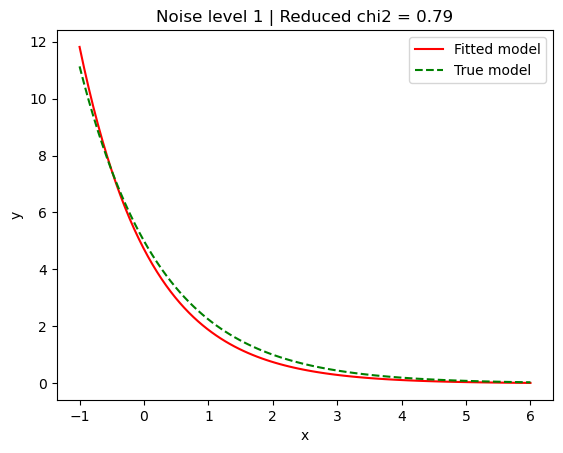

In [10]:
def model(x, A, k):
    return A * np.exp(-k * x)

x = df["x"].values
y_noise_1 = df["y_noise_1"].values 

p0 = [1,1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt

print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2/dof 
print(f"Reduced chi-squared: {chi2_reduced:.2f}")

plt.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted model")
plt.plot(x, model(x, 5, 0.8), linestyle="--", color="green", label="True model")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Noise level 1 | Reduced chi2 = {chi2_reduced:.2f}")
plt.legend()

plt.show()

In [4]:
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    
    A_fit, k_fit = popt
    
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    
    return A_fit, k_fit, chi2_reduced

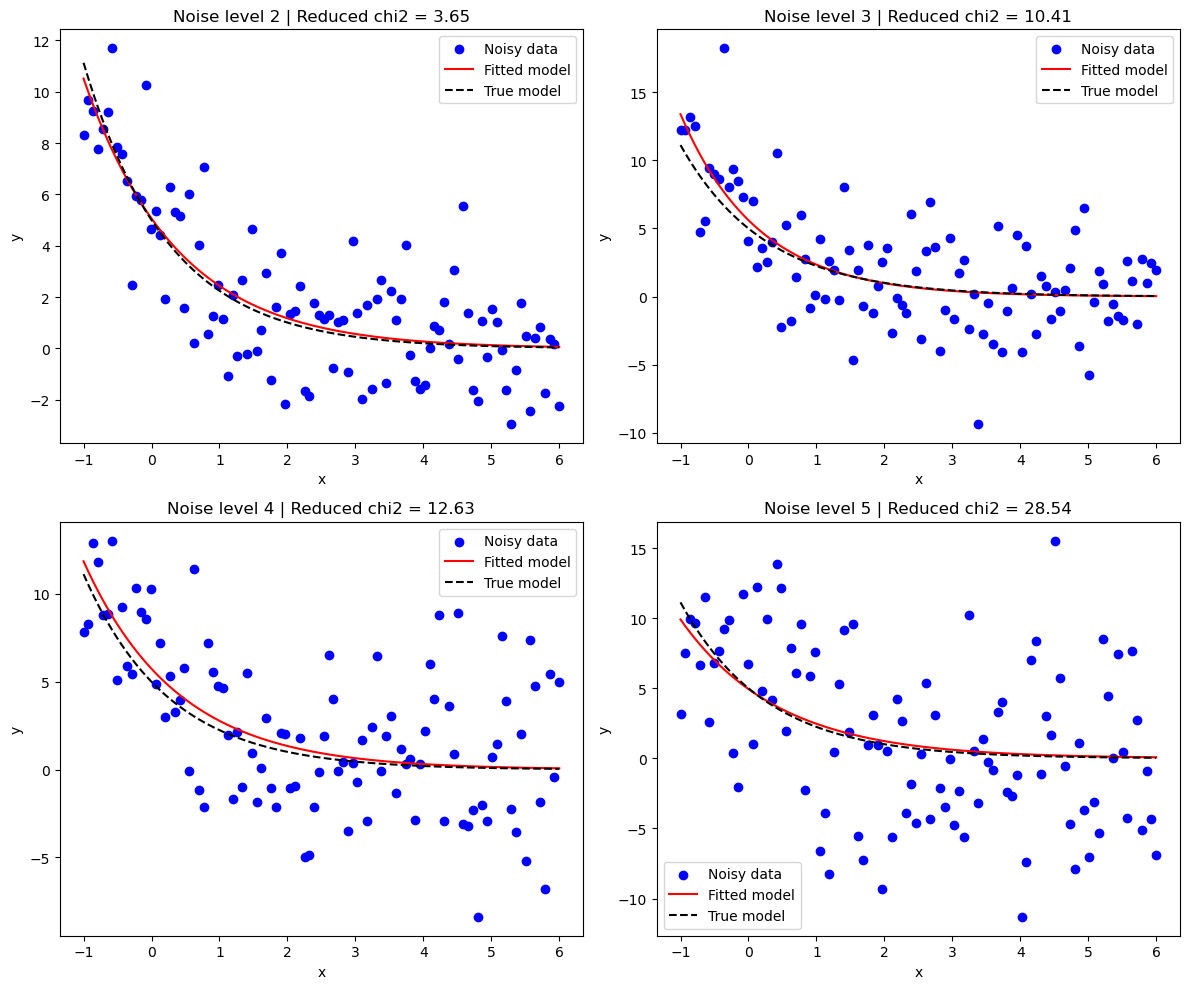

In [11]:
noise_cols = ["y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, noise_cols), start=2):
    y = df[col].values
    
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    
    ax.scatter(x, y, color="blue", label="Noisy data")
    ax.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted model")
    ax.plot(x, model(x, 5, 0.8), color="black", linestyle="--", label="True model")
    
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Noise level {i} | Reduced chi2 = {chi2_reduced:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

In [12]:
results = []

for i in range(1, 6):
    col = f"y_noise_{i}"
    y = df[col].values
    
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    
    results.append([i, A_fit, k_fit, chi2_reduced])

results_df = pd.DataFrame(results, columns=[
    "noise_level", "A_fit", "k_fit", "chi2_reduced"
])

results_df

,noise_level,A_fit,k_fit,chi2_reduced
0,1,4.714814,0.918308,0.790673
1,2,5.063889,0.730396,3.649382
2,3,5.609396,0.870372,10.410207
3,4,5.738727,0.725965,12.626832
4,5,4.943458,0.695012,28.538124


In [14]:
results_df.to_csv("noisy_parameters.csv", index=False)

In [15]:
import os
os.listdir()

['S26_cf_demo_data.csv',
 'Lecture_14_pandas.ipynb',
 '.config',
 'Music',
 'Project 1.pdf',
 '<!DOCTYPE html>.py',
 'Lectures_16_and_17.ipynb',
 'Untitled1.ipynb',
 'PiElectrical',
 '.DS_Store',
 '.CFUserTextEncoding',
 'homework9.ipynb',
 '.xonshrc',
 'anaconda_projects',
 'Untitled.ipynb',
 '.zshrc',
 'spectrum.csv',
 'Lectures_18_and_19.ipynb',
 '.local',
 'exoplanet_test_1.py',
 'matplotlib.ipynb',
 'Pictures',
 'python_decal_sp26',
 '.zprofile',
 'Dolphin_Scientific_Map.html',
 'astropy_data.fits',
 '.zsh_history',
 'Untitled2.ipynb',
 '.ipython',
 'Desktop',
 'Library',
 '.matplotlib',
 'noisy_parameters.csv',
 '.lesshst',
 'candidates_scored.csv',
 'noisy_curvefit_data.csv',
 '.cups',
 'Sites',
 'python_dolphin_odyssey.ipynb',
 'Public',
 '.tcshrc',
 'python_dolphin_odyssey.py',
 '.virtual_documents',
 'Dolphin_Odyssey.html',
 'solar_system.csv',
 'Dolphin_Odyssey_trial1.py',
 '.anaconda',
 'print("Hello, World!").py',
 '.ssh',
 'Movies',
 'Applications',
 'print("hello").py',


In [16]:
df_check = pd.read_csv("noisy_parameters.csv")
df_check

,noise_level,A_fit,k_fit,chi2_reduced
0,1,4.714814,0.918308,0.790673
1,2,5.063889,0.730396,3.649382
2,3,5.609396,0.870372,10.410207
3,4,5.738727,0.725965,12.626832
4,5,4.943458,0.695012,28.538124


In [17]:
os.path.exists("noisy_parameters.csv")

True